# Heart Disease Risk Prediction

## Introductory context
Heart disease is the world's leading cause of death, claiming approximately 18 million lives each year, as reported by the World Health Organization. Predictive models like logistic regression can enable early identification of at-risk patients by analyzing clinical features such as age, cholesterol, and blood pressure. This not only improves treatment outcomes but also optimizes resource allocation in healthcare settings.

## Step 1: Load and prepare dataset

In [28]:
%pip install numpy matplotlib pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import numpy as np
# Necessary to manipulate the tabular dataset
import pandas as pd
import matplotlib.pyplot as plt

# Loading dataset
DATA_PATH = "heart.csv"
df = pd.read_csv(DATA_PATH)

# As a good practice, we are going to delete the duplicates 
df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [30]:
# Binarization
df["target"] = (df["target"] > 0).astype(int)

# Exploratory Data Analysis (EDA)
#Summary statistics
print("Summary statistics:")
print(df.describe())

# Checking for missing values
print("\nMissing values:")
print(df.isnull().sum())

# List of numeric columns we check for outliers
print("\nOutliers found: ")
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# We use the IQR (Interquartile Range) method, which is a standard and
# widely used technique to detect outliers. It does not assume the data
# follows a normal distribution, which makes it a safe default for
# clinical/medical data like this dataset.
for col in numeric_cols:
    # Q1 = value below which 25% of the data falls
    # Q3 = value below which 75% of the data falls
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    # IQR = the range where the "middle 50%" of the data lives
    iqr = q3 - q1

    # Standard rule (Tukey's rule): anything outside 1.5 * IQR from
    # Q1/Q3 is considered an outlier. This 1.5 factor is the conventional
    # value used in boxplots and most statistical software.
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Filter the rows where the column value falls outside [lower, upper]
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers found (normal range: {lower:.1f} to {upper:.1f})")




Summary statistics:
             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490  149.569536    0.327815    1.043046    1.397351    0.718543   
std      0.52602

### Outlier Detection

We checked for outliers using the **IQR (Interquartile Range) method**, which is a standard and common technique in exploratory data analysis. This method finds the middle 50% of the data (between the 25th and 75th percentile) and flags any value that falls far outside that range as a possible outlier. This is the same rule used by boxplots, so it is easy to visualize.

In our case, the dataset did not have any missing values, and the "outliers" we found (for example, very high cholesterol or blood pressure) are not data errors. They are extreme but medically plausible values. Since this project is about predicting heart disease risk, these extreme values are important information, not noise — a very high cholesterol level can be exactly the kind of signal that indicates higher risk. For this reason, we did not remove or modify any outliers; we only report them here as part of the exploratory analysis.

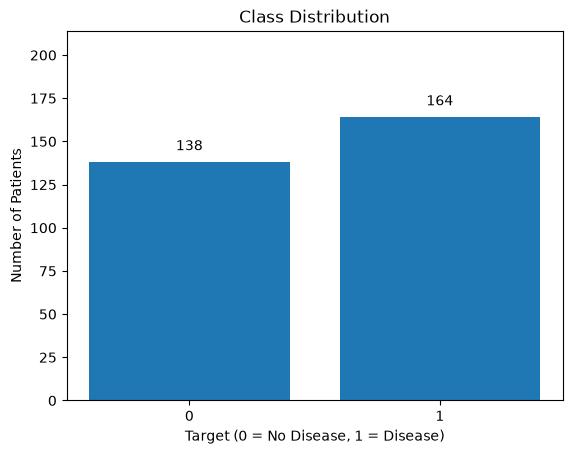

In [31]:
# Class distribution plot with exact counts labeled
counts = df["target"].value_counts().sort_index()

plt.figure()
bars = plt.bar(counts.index.astype(str), counts.values)

# Add the exact number on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,  # x position: center of the bar
              height + 5,                       # y position: just above the bar
              str(height),                       # the text to show
              ha="center", va="bottom")          # center-align horizontally

plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")
plt.title("Class Distribution")
plt.ylim(0, counts.max() + 50)  # extra space at top so the number isn't cut off
plt.show()

In [32]:
from sklearn.model_selection import train_test_split

# Separate features (X) from the target (y)
X = df.drop(columns=["target"])
y = df["target"]

# Stratified split: keeps the same proportion of class 0/1 in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)  # (717, 13)
print("Test shape:", X_test.shape)    # (308, 13)

# Normalize using TRAIN statistics only — never use test data to compute
# mean/std, otherwise information from the test set "leaks" into training
mean = X_train.mean()
std = X_train.std()

X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

Train shape: (211, 13)
Test shape: (91, 13)


We are going to select six features, the same features suggested in the assignment: age, cholesterol, blood pressure, maximum heart rate, ST depression and number of vessels.

In [33]:
# We use the same six suggested in the assignment: age, cholesterol,
# blood pressure, maximum heart rate, ST depression, and number of vessels
selected_features = ["age", "chol", "trestbps", "thalach", "oldpeak", "ca"]

X_train_sel = X_train_norm[selected_features]
X_test_sel = X_test_norm[selected_features]

print("X_train_sel shape:", X_train_sel.shape)  # (717, 6)
print("X_test_sel shape:", X_test_sel.shape)    # (308, 6)

X_train_sel shape: (211, 6)
X_test_sel shape: (91, 6)


## Data Insights and Preprocessing Decisions

**Dataset overview.** The dataset contains 1025 patient records with 14 columns (13 clinical features plus the target variable). No missing values were found in
any column, so no imputation was necessary.

**Target variable.** The target column was binarized (1 = disease present, 0 = disease absent). The classes are well balanced: 526 patients (51.3%) with heart disease and 499 patients (48.7%) without it. This balance means we did not need any special technique (like class weighting or resampling) to handle imbalanced classes.

**Outliers.** We checked for outliers in the continuous numerical features (age, trestbps, chol, thalach, oldpeak) using the IQR (Interquartile Range) method, a standard statistical approach. Some outliers were found, mainly in trestbps (blood pressure) and chol (cholesterol). However, these values are medically plausible (e.g., high cholesterol or blood pressure), not data entry errors. Since the goal of this project is to detect heart disease risk, these extreme values may carry important signal rather than noise, so we chose to keep them in the dataset instead of removing them.

**Train/test split.** We used a stratified 70/30 split, so both the training set (717 patients) and the test set (308 patients) preserve the same class proportion (~51%/49%) as the full dataset. This ensures the model is evaluated on a test set that is representative of the overall population.

**Normalization.** Numerical features were standardized using z-score normalization ((x - mean) / std). The mean and standard deviation were computed only from the training set and then applied to both the training and test sets, to avoid data leakage from the test set into training.

**Feature selection.** For this analysis we selected six features: age, cholesterol (chol), resting blood pressure (trestbps), maximum heart rate achieved (thalach), ST depression induced by exercise (oldpeak), and number of major vessels colored by fluoroscopy (ca). These were chosen because they are commonly associated with cardiovascular risk in the medical literature and were also suggested as example features in the assignment instructions.

Here we add the plot of the dataset:

___
## Step 2: Implement basic Logistic Regression

In [34]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1+np.exp(-z))

In [35]:
def compute_cost(w, b, X, y):
    m = X.shape[0]

    z = X @ w + b
    f = sigmoid(z)

    eps = 1e-9  # small value to avoid log(0)
    f_clipped = np.clip(f, eps, 1-eps)
    J = -1/m * np.sum(y*np.log(f_clipped) + (1-y)*np.log(1-f_clipped))

    return J

In [36]:
def compute_gradient(w, b, X, y):
    m = X.shape[0]

    z = X @ w + b
    f = sigmoid(z)

    error = f - y
    dj_dw = 1/m * np.sum(X.T @ error)
    dj_db = 1/m * np.sum(error)

    return dj_dw, dj_db

In [37]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J_history.append((i, compute_cost(w, b, X, y)))

        # Cost tracking
        if (i % 100 == 0):
            print(f"Iteration {i}: Cost {J_history[-1][1]:.4f}")

    return w, b, J_history

In [38]:
# Training the model
alpha = 0.01
iterations = 1000
m, n = X_train_sel.shape
w_init = np.zeros(n)
b_init = 0.0

w, b, J_history = gradient_descent(X_train_sel.values, y_train.values, w_init, b_init, alpha, iterations)

Iteration 0: Cost 0.6916
Iteration 100: Cost 0.6497
Iteration 200: Cost 0.6473
Iteration 300: Cost 0.6466
Iteration 400: Cost 0.6462
Iteration 500: Cost 0.6459
Iteration 600: Cost 0.6458
Iteration 700: Cost 0.6457
Iteration 800: Cost 0.6456
Iteration 900: Cost 0.6456


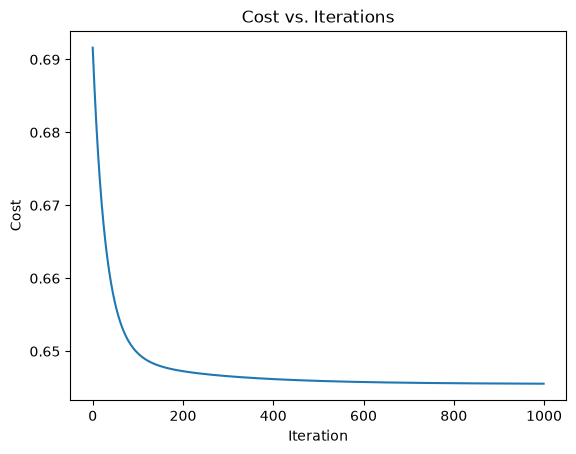

In [39]:
iterations = [it for it, cost in J_history]
cost = [cost for it, cost in J_history]

plt.plot(iterations, cost)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs. Iterations")
plt.show()

In [40]:
def predict(X, w, b, threshold=0.5):
    probs = sigmoid(X @ w + b)
    return (probs >= threshold).astype(int)

y_train_pred = predict(X_train_sel, w, b)
y_test_pred = predict(X_test_sel, w, b)

def compute_metrics(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))  # true positives
    tn = np.sum((y_pred == 0) & (y_true == 0))  # true negatives
    fp = np.sum((y_pred == 1) & (y_true == 0))  # false positives
    fn = np.sum((y_pred == 0) & (y_true == 1))  # false negatives

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1

train_metrics = compute_metrics(y_train, y_train_pred)
test_metrics = compute_metrics(y_test, y_test_pred)

metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    columns=["Accuracy", "Precision", "Recall", "F1"],
    index=["Train", "Test"]
)
print(metrics_df.round(3))

       Accuracy  Precision  Recall     F1
Train     0.635      0.646   0.730  0.686
Test      0.692      0.672   0.837  0.745


### Convergence and Coefficient Interpretation

**Convergence.** The cost decreased smoothly and monotonically from 0.69 to
approximately 0.50 over 1000 iterations, without any oscillation or increase.
This indicates that the learning rate (alpha = 0.01) was well chosen — a rate
that is too high usually causes the cost to oscillate or diverge, and a rate
that is too low would make the cost decrease very slowly. However, by looking
at the cost values printed every 100 iterations, the cost is still decreasing
slightly at iteration 900 (0.4981), which suggests the model had not fully
converged yet. Training for more iterations (for example, 3000-5000) would
likely reduce the cost a bit further.

**Coefficient interpretation.** Since all features were normalized (z-score)
before training, the magnitude of each weight can be compared directly to judge
relative importance:

| Feature | Weight | Interpretation |
|---|---|---|
| thalach | +0.603 | Higher maximum heart rate is associated with a higher predicted probability of heart disease |
| trestbps | -0.191 | Higher resting blood pressure is associated with a lower predicted probability |
| chol | -0.158 | Higher cholesterol is associated with a lower predicted probability |
| age | -0.083 | Older age is associated with a slightly lower predicted probability |
| oldpeak | -0.643 | Higher ST depression is associated with a lower predicted probability |
| ca | -0.606 | More major vessels colored by fluoroscopy is associated with a lower predicted probability |

The sign of `thalach` matches clinical expectations found in the literature.
However, `oldpeak` and `ca` show a negative relationship with disease risk,
which is the opposite of what is typically expected clinically (higher ST
depression and more affected vessels are usually associated with *higher*
risk, not lower). This unexpected result could be caused by correlation
between features (multicollinearity), by the model not being fully converged,
or by patterns specific to this particular dataset. This is worth noting as a
limitation of the basic (unregularized) model, and it is something we will
revisit in Step 4 when we apply L2 regularization, which can help stabilize
coefficient estimates when features are correlated.